<a href="https://colab.research.google.com/github/tungduong03/Deep-Learning/blob/main/secBERT_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import transformers
from transformers import AutoModel, BertTokenizerFast

In [3]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Code_Injection_Dataset
df = pd.read_csv('dataset_capec.csv')  # Đọc file CSV
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Code_Injection_Dataset


,text,label
0,GET /blog/index.php/2020/04/04/voluptatum-repr...,000 - Normal
1,GET /blog/xmlrpc.php?rsd,000 - Normal
2,GET /blog/index.php/2020/04/04/nihil-tenetur-e...,000 - Normal
3,GET /blog/index.php/2020/04/04/explicabo-qui-f...,000 - Normal
4,GET /blog/index.php/2020/04/04/explicabo-qui-f...,000 - Normal


In [4]:
# Đếm số lượng record cho mỗi loại label
label_counts = df['label'].value_counts()

# Lọc các label có số lượng record > 20000
labels_above_20000 = label_counts[label_counts > 20000].index

# Lấy 20,000 record đầu tiên cho các label đó
df_above_20000 = df[df['label'].isin(labels_above_20000)]
df_above_20000 = df_above_20000.groupby('label').head(20000)

# Lấy các record còn lại (cho các label không có số lượng lớn hơn 20000)
df_below_20000 = df[~df['label'].isin(labels_above_20000)]

# Ghép các record lại với nhau
df_combined = pd.concat([df_below_20000, df_above_20000])

# Xáo trộn dữ liệu sau khi ghép
df_combined = df_combined.sample(frac=1).reset_index(drop=True)
df = df_combined

print(df_combined)

                                                     text  \
0       GET /blog/index.php/2020/04%22+AND+%221%22%3D%...   
1       GET /blog/index.php/2020%27%29+UNION+ALL+selec...   
2       GET /blog/index.php/my-account/%252F..%252F..%...   
3       GET /blog+AND+1%3D1+--+/index.php/2020/04/04/i...   
4       GET /blog/index.php/www.google.com%2Fsearch%3F...   
...                                                   ...   
121209                    GET /%2F27/index.php/2020/03/27   
121210  OPTIONS /blog/wp-comments-post.php comment=&au...   
121211  GET /%2F..%2F..%2F..%2F..%2F..%2F..%2F..%2F..%...   
121212  GET /%2Fcommodi-ut-sint-sequi-excepturi/index....   
121213  GET /any%3F%0D%0ASet-cookie%3A+Tamper%3Dcfa7f4...   

                                label  
0                  66 - SQL Injection  
1                  66 - SQL Injection  
2                126 - Path Traversal  
3                  66 - SQL Injection  
4       194 - Fake the Source of Data  
...                        

In [5]:
# Optional (not effect very much)
df['text'] = df['text'].str.replace('/',' ')
df.head()

,text,label
0,GET blog index.php 2020 04%22+AND+%221%22%3D%...,66 - SQL Injection
1,GET blog index.php 2020%27%29+UNION+ALL+selec...,66 - SQL Injection
2,GET blog index.php my-account %252F..%252F..%...,126 - Path Traversal
3,GET blog+AND+1%3D1+--+ index.php 2020 04 04 i...,66 - SQL Injection
4,GET blog index.php www.google.com%2Fsearch%3F...,194 - Fake the Source of Data


In [6]:
# check class distribution
df['label'].value_counts(normalize = True)

,proportion
label,
66 - SQL Injection,0.164997
194 - Fake the Source of Data,0.164997
000 - Normal,0.164997
34 - HTTP Response Splitting,0.157853
126 - Path Traversal,0.145157
242 - Code Injection,0.113782
272 - Protocol Manipulation,0.057122
310 - Scanning for Vulnerable Software,0.019651
153 - Input Data Manipulation,0.011443


In [7]:
# split train dataset into train, validation and test sets
train_text, temp_text, train_labels, temp_labels = train_test_split(df['text'], df['label'],
                                                                    random_state=2018,
                                                                    test_size=0.3,
                                                                    stratify=df['label'])


val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels,
                                                                random_state=2018,
                                                                test_size=0.5,
                                                                stratify=temp_labels)

In [8]:
# Load model directly
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("jackaduma/SecBERT")
bert = AutoModel.from_pretrained("jackaduma/SecBERT")


from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
label_encoder = LabelEncoder()
# Fit the encoder on the original labels
label_encoder.fit(df['label'])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/378k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/336M [00:00<?, ?B/s]

LabelEncoder()

<Axes: >

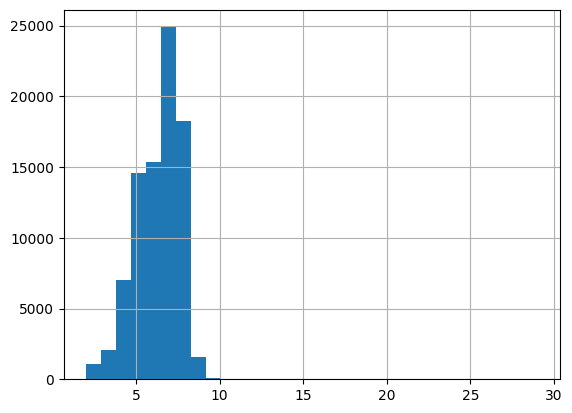

In [10]:
# get length of all the messages in the train set
seq_len = [len(i.split()) for i in train_text]

pd.Series(seq_len).hist(bins = 30)

In [11]:
max_length = 20

# tokenize and encode sequences in the training set
tokens_train = tokenizer.batch_encode_plus(
    train_text.tolist(),
    max_length = max_length,
    padding=True,
    truncation=True
)

# tokenize and encode sequences in the validation set
tokens_val = tokenizer.batch_encode_plus(
    val_text.tolist(),
    max_length = max_length,
    padding=True,
    truncation=True
)

# tokenize and encode sequences in the test set
tokens_test = tokenizer.batch_encode_plus(
    test_text.tolist(),
    max_length = max_length,
    padding=True,
    truncation=True
)

In [12]:
## convert lists to tensors

train_y = torch.tensor(label_encoder.transform(train_labels))
val_y = torch.tensor(label_encoder.transform(val_labels))
test_y = torch.tensor(label_encoder.transform(test_labels))

train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])


val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])


test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])


In [13]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

#define a batch size
batch_size = 32

# wrap tensors
train_data = TensorDataset(train_seq, train_mask, train_y)

# sampler for sampling the data during training
train_sampler = RandomSampler(train_data)

# dataLoader for train set
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

# wrap tensors
val_data = TensorDataset(val_seq, val_mask, val_y)

# sampler for sampling the data during training
val_sampler = SequentialSampler(val_data)

# dataLoader for validation set
val_dataloader = DataLoader(val_data, sampler = val_sampler, batch_size=batch_size)

In [14]:
# freeze all the parameters
for param in bert.parameters():
    param.requires_grad = False

In [15]:
class BERT_Arch(nn.Module):

    def __init__(self, bert):
        super(BERT_Arch, self).__init__()

        self.bert = bert

        # dropout layer
        self.dropout = nn.Dropout(0.1)

        # relu activation function
        self.relu =  nn.ReLU()

        # dense layer 1
        self.fc1 = nn.Linear(768,512)

        # dense layer 2
        self.fc2 = nn.Linear(512,256)

        # dense layer 3 (Output layer)
        self.fc3 = nn.Linear(256,9)

        #softmax activation function
        self.softmax = nn.LogSoftmax(dim=1)

    #define the forward pass
    def forward(self, sent_id, mask):

        #pass the inputs to the model
        outputs = self.bert(sent_id, attention_mask=mask, return_dict=True)
        cls_hs = outputs.last_hidden_state[:, 0, :] #extract the CLS token embedding, which is used for classification

        x = self.fc1(cls_hs)

        x = self.relu(x)

        x = self.dropout(x)

        # output layer
        x = self.fc2(x)
        x = self.fc3(x)

        # apply softmax activation
        x = self.softmax(x)

        return x

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# pass the pre-trained BERT to our define architecture
model = BERT_Arch(bert)

# push the model to GPU
model = model.to(device)

cuda


In [17]:
# optimizer from hugging face transformers
from transformers import AdamW

# define the optimizer
optimizer = AdamW(model.parameters(),lr = 1e-5)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [18]:
from sklearn.utils.class_weight import compute_class_weight

# Tính toán trọng số cho các lớp (ở đây là 9 nhãn)
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)

# In ra trọng số các lớp
print("Class Weights:", class_weights)


Class Weights: [0.67340476 0.76548122 9.70923447 0.67340476 0.97655549 1.94505192
 5.65546891 0.70387238 0.67340476]


In [19]:
# converting list of class weights to a tensor
weights= torch.tensor(class_weights,dtype=torch.float)

# push to GPU
weights = weights.to(device)

# define the loss function
cross_entropy  = nn.NLLLoss(weight=weights)

# number of training epochs
epochs = 10

In [20]:
# function to train the model
def train():

    model.train()
    total_loss, total_accuracy = 0, 0

    # empty list to save model predictions
    total_preds=[]

    # iterate over batches
    for step,batch in enumerate(train_dataloader):

        # progress update after every 50 batches.
        if step % 1000 == 0 and not step == 0:
            print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(train_dataloader)))

        # push the batch to gpu
        batch = [r.to(device) for r in batch]

        sent_id, mask, labels = batch

        # clear previously calculated gradients
        model.zero_grad()

        # get model predictions for the current batch
        preds = model(sent_id, mask)

        # compute the loss between actual and predicted values
        loss = cross_entropy(preds, labels)

        # add on to the total loss
        total_loss = total_loss + loss.item()

        # backward pass to calculate the gradients
        loss.backward()

        # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # update parameters
        optimizer.step()

        # model predictions are stored on GPU. So, push it to CPU
        preds=preds.detach().cpu().numpy()

    # append the model predictions
    total_preds.append(preds)

    # compute the training loss of the epoch
    avg_loss = total_loss / len(train_dataloader)

      # predictions are in the form of (no. of batches, size of batch, no. of classes).
      # reshape the predictions in form of (number of samples, no. of classes)
    total_preds  = np.concatenate(total_preds, axis=0)

    #returns the loss and predictions
    return avg_loss, total_preds

In [21]:
# function for evaluating the model
import time
def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    elapsed_rounded = int(round((elapsed)))
    return str(time.strftime("%H:%M:%S", time.gmtime(elapsed_rounded)))

def evaluate():

    print("\nEvaluating...")

    # deactivate dropout layers
    model.eval()

    total_loss, total_accuracy = 0, 0

    # empty list to save the model predictions
    total_preds = []

    t0 = time.time()

    # iterate over batches
    for step,batch in enumerate(val_dataloader):

        # Progress update every 500 batches.
        if step % 1000 == 0 and not step == 0:

            # Calculate elapsed time in minutes.
            elapsed = format_time(time.time() - t0)

            # Report progress.
            print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(val_dataloader)))

        # push the batch to gpu
        batch = [t.to(device) for t in batch]

        sent_id, mask, labels = batch

        # deactivate autograd
        with torch.no_grad():

            # model predictions
            preds = model(sent_id, mask)

            # compute the validation loss between actual and predicted values
            loss = cross_entropy(preds,labels)

            total_loss = total_loss + loss.item()

            preds = preds.detach().cpu().numpy()

            total_preds.append(preds)

    # compute the validation loss of the epoch
    avg_loss = total_loss / len(val_dataloader)

    # reshape the predictions in form of (number of samples, no. of classes)
    total_preds  = np.concatenate(total_preds, axis=0)

    return avg_loss, total_preds

In [22]:
print(model)

BERT_Arch(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=0)
      (position_embeddings): Embedding(514, 768)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-5): 6 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affin

In [23]:
# set initial loss to infinite
best_valid_loss = float('inf')

# empty lists to store training and validation loss of each epoch
train_losses=[]
valid_losses=[]

#for each epoch
for epoch in range(epochs):

    print('\n Epoch {:} / {:}'.format(epoch + 1, epochs))

    #train model
    train_loss, _ = train()

    #evaluate model
    valid_loss, _ = evaluate()

    #save the best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'saved_weights.pt')

    # append training and validation loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'\nTraining Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')


 Epoch 1 / 10
  Batch 1,000  of  2,652.
  Batch 2,000  of  2,652.

Evaluating...

Training Loss: 0.943
Validation Loss: 0.461

 Epoch 2 / 10
  Batch 1,000  of  2,652.
  Batch 2,000  of  2,652.

Evaluating...

Training Loss: 0.474
Validation Loss: 0.385

 Epoch 3 / 10
  Batch 1,000  of  2,652.
  Batch 2,000  of  2,652.

Evaluating...

Training Loss: 0.425
Validation Loss: 0.353

 Epoch 4 / 10
  Batch 1,000  of  2,652.
  Batch 2,000  of  2,652.

Evaluating...

Training Loss: 0.400
Validation Loss: 0.337

 Epoch 5 / 10
  Batch 1,000  of  2,652.
  Batch 2,000  of  2,652.

Evaluating...

Training Loss: 0.385
Validation Loss: 0.327

 Epoch 6 / 10
  Batch 1,000  of  2,652.
  Batch 2,000  of  2,652.

Evaluating...

Training Loss: 0.375
Validation Loss: 0.319

 Epoch 7 / 10
  Batch 1,000  of  2,652.
  Batch 2,000  of  2,652.

Evaluating...

Training Loss: 0.366
Validation Loss: 0.319

 Epoch 8 / 10
  Batch 1,000  of  2,652.
  Batch 2,000  of  2,652.

Evaluating...

Training Loss: 0.359
Validat

In [24]:
#load weights of best model
path = 'saved_weights.pt'
model.load_state_dict(torch.load(path))

<ipython-input-24-5a29cc8ec3f6>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


<All keys matched successfully>

In [26]:
# get predictions for test data in batches
batch_size = 32  # Adjust batch size as needed
all_preds = []

with torch.no_grad():
    for i in range(0, test_seq.shape[0], batch_size):
        # Get batch of test data
        batch_seq = test_seq[i:i + batch_size].to(device)
        batch_mask = test_mask[i:i + batch_size].to(device)

        # Get predictions for the batch
        preds = model(batch_seq, batch_mask)
        preds = preds.detach().cpu().numpy()

        # Append predictions to the list
        all_preds.append(preds)

# Concatenate all predictions
preds = np.concatenate(all_preds, axis=0)

In [27]:
# model's performance
preds = np.argmax(preds, axis = 1)

label_names = label_encoder.classes_  # Lấy danh sách tên nhãn

print(classification_report(test_y, preds, target_names=label_names))

                                        precision    recall  f1-score   support

                          000 - Normal       0.97      0.75      0.85      3000
                  126 - Path Traversal       0.99      0.87      0.93      2640
         153 - Input Data Manipulation       0.37      1.00      0.54       208
         194 - Fake the Source of Data       0.99      0.93      0.96      3000
                  242 - Code Injection       0.99      0.95      0.97      2069
           272 - Protocol Manipulation       0.51      0.80      0.63      1039
310 - Scanning for Vulnerable Software       0.96      0.99      0.98       357
          34 - HTTP Response Splitting       1.00      0.92      0.96      2870
                    66 - SQL Injection       0.82      0.98      0.90      3000

                              accuracy                           0.89     18183
                             macro avg       0.85      0.91      0.86     18183
                          weighted avg

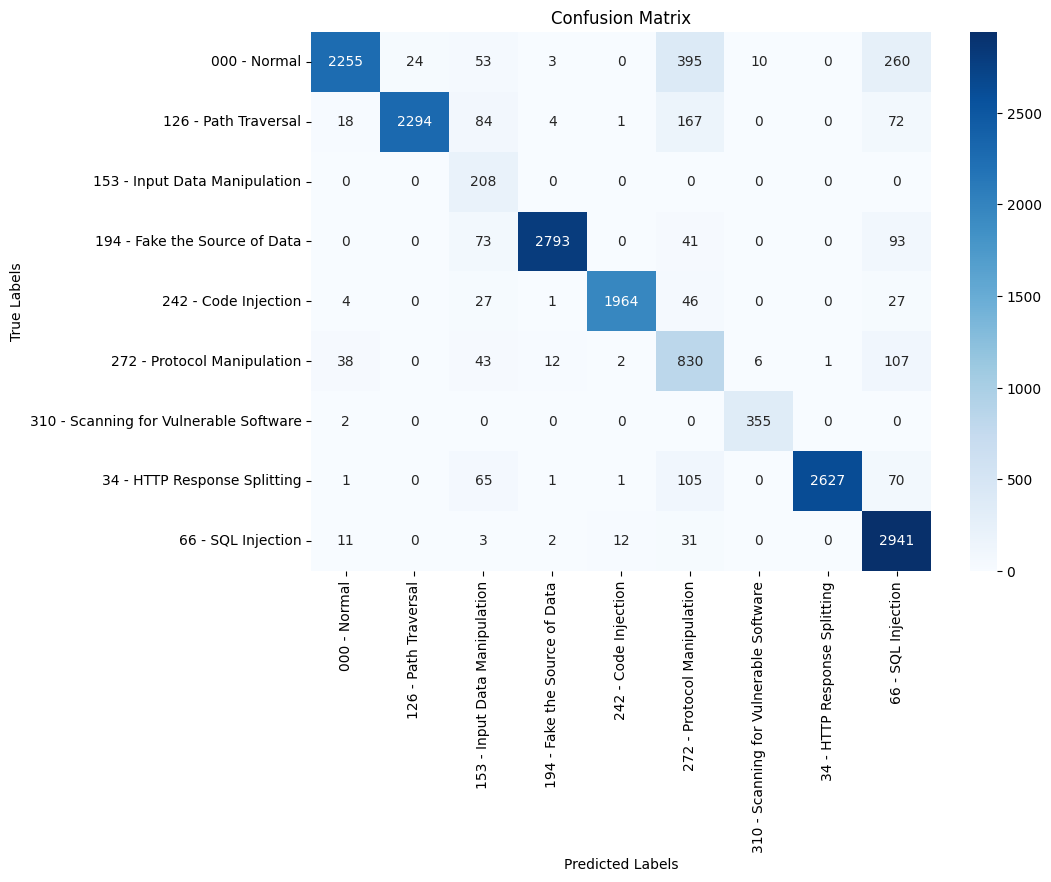

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Tính confusion matrix
cm = confusion_matrix(test_y, preds)

# Vẽ confusion matrix bằng heatmap
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [29]:
# Đoạn text cần dự đoán
text = "GET blog index.php 2020 04 04%27%29+UNION+ALL+select+NULL+--"



# Tokenize và mã hóa đoạn văn bản
tokens = tokenizer.encode_plus(
    text,
    max_length=15,  # Độ dài tối đa phù hợp với mô hình
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

# Chuyển dữ liệu sang thiết bị
input_ids = tokens['input_ids'].to(device)
attention_mask = tokens['attention_mask'].to(device)

# Dự đoán
with torch.no_grad():
    output = model(input_ids, attention_mask)
    prediction = torch.argmax(output, dim=1).item()

# Giải mã nhãn số thành tên nhãn
predicted_label = label_encoder.inverse_transform([prediction])[0]
print(f"{predicted_label}")


66 - SQL Injection
